In [2]:
import numpy as np 
import pickle
import pandas as pd

loaded = np.load('connectomes_harm_compressed.npz')
connectomes_harm = loaded['connectomes']
with open('data_harm.pkl', 'rb') as f:
    data_harm = pickle.load(f)

In [3]:
# connectomes_harm is 3D (n_subjects, 90, 90), so reshape to 2D first

df_harm = pd.DataFrame(connectomes_harm.reshape(connectomes_harm.shape[0], -1))

df_harm['age'] = data_harm['age'].to_numpy()

df_harm.head()

df_harm.shape
df_harm.tail()



,0,1,2,3,4,5,6,7,8,9,...,8091,8092,8093,8094,8095,8096,8097,8098,8099,age
3797,0.0,0.000000,0.580083,0.058154,0.125389,0.000000,0.398513,0.0,0.015673,0.0,...,0.000000,0.0,0.0,0.0,0.524952,0.0,0.024535,0.0,0.0,38
3798,0.0,0.000000,0.020657,0.032556,0.167243,0.000000,0.156980,0.0,0.000000,0.0,...,0.000000,0.0,0.0,0.0,0.100876,0.0,0.025452,0.0,0.0,47
3799,0.0,0.227975,0.346221,0.178066,0.143092,0.155782,0.233376,0.0,0.199113,0.0,...,0.047532,0.0,0.0,0.0,0.182959,0.0,0.056780,0.0,0.0,41
3800,0.0,0.000000,0.252247,0.000000,0.068915,0.000000,0.042776,0.0,0.000000,0.0,...,0.000000,0.0,0.0,0.0,0.186812,0.0,0.000000,0.0,0.0,87
3801,0.0,0.000000,0.282014,0.000000,0.081989,0.000000,0.170989,0.0,0.050853,0.0,...,0.000000,0.0,0.0,0.0,0.425853,0.0,0.083945,0.0,0.0,54


In [4]:
df_harm['age_group'] = pd.cut(df_harm['age'], bins=[0, 10, 20, 30, 40, 50, 60, 70, 80, 90], labels=['0-10', '10-20', '20-30', '30-40', '40-50', '50-60', '60-70', '70-80', '80-90'])

age_group_counts = df_harm['age_group'].value_counts().sort_index()

#group by age group and calculate mean connectome for each group
grouped_means = df_harm.groupby('age_group').mean()


C:\Users\Ale\AppData\Local\Temp\ipykernel_11676\404967543.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_means = df_harm.groupby('age_group').mean()


In [5]:
grouped_means.shape
grouped_means


,0,1,2,3,4,5,6,7,8,9,...,8091,8092,8093,8094,8095,8096,8097,8098,8099,age
age_group,,,,,,,,,,,,,,,,,,,,,
0-10,0.0,0.062439,0.117395,0.019743,0.026693,0.005134,0.078697,0.000375,0.011065,0.000000,...,0.011391,0.000467,0.003508,0.000518,0.193750,0.002239,0.023371,0.004396,0.0,7.122340
10-20,0.0,0.098750,0.131330,0.034441,0.048028,0.028853,0.070862,0.000507,0.023953,0.000129,...,0.010849,0.000090,0.002372,0.000444,0.185705,0.001857,0.020563,0.002826,0.0,14.647619
20-30,0.0,0.093611,0.145955,0.032230,0.070529,0.037870,0.092977,0.001940,0.030526,0.000100,...,0.011855,0.000328,0.003530,0.000531,0.207388,0.001522,0.027785,0.007057,0.0,26.129268
30-40,0.0,0.119442,0.157478,0.040250,0.070420,0.050377,0.105034,0.002291,0.034742,0.000000,...,0.012170,0.000417,0.004489,0.000053,0.205387,0.001734,0.031715,0.004887,0.0,34.011152
40-50,0.0,0.129841,0.184313,0.054576,0.083076,0.064824,0.128853,0.003075,0.037894,0.000061,...,0.008820,0.000203,0.004896,0.000178,0.231697,0.000801,0.039946,0.004035,0.0,45.342412
50-60,0.0,0.098780,0.183899,0.041824,0.088887,0.043994,0.137598,0.000394,0.044666,0.000000,...,0.013693,0.000000,0.002593,0.000730,0.249263,0.001123,0.039151,0.003162,0.0,55.455645
60-70,0.0,0.064691,0.209192,0.024814,0.108743,0.034582,0.141872,0.000717,0.049630,0.000384,...,0.010688,0.000669,0.005227,0.000454,0.279243,0.001116,0.044211,0.003665,0.0,65.475983
70-80,0.0,0.028074,0.210134,0.011549,0.105617,0.018160,0.151660,0.001439,0.037257,0.000311,...,0.009093,0.000000,0.008627,0.000219,0.236588,0.000752,0.049645,0.001662,0.0,75.524887
80-90,0.0,0.015403,0.225271,0.006762,0.130288,0.008874,0.156958,0.000129,0.060511,0.000000,...,0.010350,0.000000,0.005331,0.000186,0.273933,0.003597,0.059766,0.002943,0.0,84.014085


In [6]:
grouped_means.to_csv('ESNcpp/average_connectomes_by_age_group.csv', index=False, header=False)

Correlation: 0.5009895337157844, P-value: 0.16949027497641286


Text(0, 0.5, 'Memory Capacity')

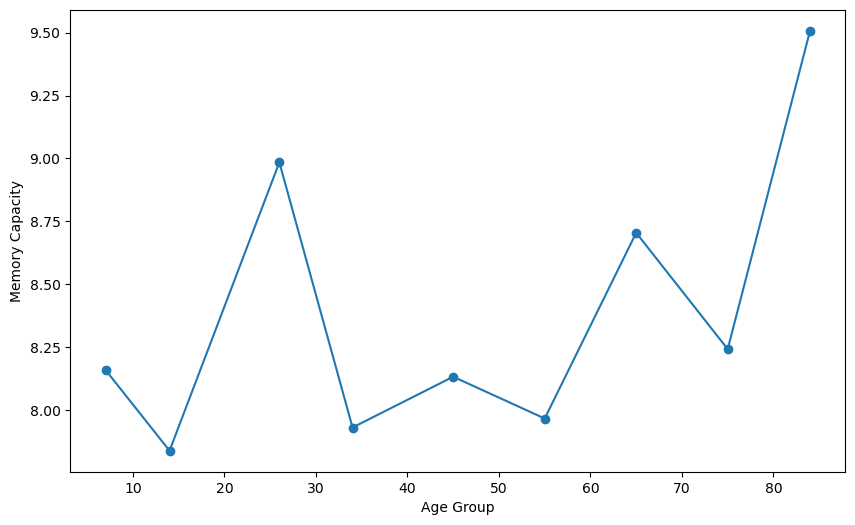

In [7]:
#start a dataframe with the correlations 
df = pd.read_csv('ESNcpp/MC_by_age_group.txt', header=None)
df.columns = ['Age Group', 'Memory Capacity']

#obtain a p value for the correlation between age group and memory capacity
from scipy.stats import pearsonr
correlation, p_value = pearsonr(df['Age Group'], df['Memory Capacity'])
print(f'Correlation: {correlation}, P-value: {p_value}')
#plot the correlation
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(df['Age Group'], df['Memory Capacity'], marker='o')
plt.xlabel('Age Group')
plt.ylabel('Memory Capacity')

Doesnt seem to be promising, we are averaging connectomes and expecting that the avg of a hihgly non linear function is like the avg of the output of that function, so we are going to process all connectomes and perform memory task in them

In [8]:

df_harm = pd.DataFrame(connectomes_harm.reshape(connectomes_harm.shape[0], -1))

df_harm['age'] = data_harm['age'].to_numpy()

df_harm.head()

,0,1,2,3,4,5,6,7,8,9,...,8091,8092,8093,8094,8095,8096,8097,8098,8099,age
0,0.0,0.0,0.049047,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.161919,0.0,0.018394,0.0,0.0,0
1,0.0,0.0,0.161241,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.008886,0.0,0.0,0.0,0.095333,0.0,0.000000,0.0,0.0,0
2,0.0,0.0,0.230027,0.0,0.0,0.0,0.032053,0.0,0.0,0.0,...,0.031211,0.0,0.0,0.0,0.214103,0.0,0.095060,0.0,0.0,0
3,0.0,0.0,0.000000,0.0,0.0,0.0,0.031190,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.205546,0.0,0.000000,0.0,0.0,0
4,0.0,0.0,0.064553,0.0,0.0,0.0,0.021145,0.0,0.0,0.0,...,0.040969,0.0,0.0,0.0,0.555048,0.0,0.230462,0.0,0.0,0


In [9]:
#df_harm.to_csv('ESNcpp/connectomes_with_age.csv', index=False, header=False) 

actually as  test we can take random 30 and sort them by age

In [10]:
df_sample = df_harm.sample(n=1000, random_state=42)
df_sample.to_csv('ESNcpp/sample_connectomes_with_age_1000.csv', index=False, header=False)

Correlation: 0.17161067510923644, P-value: 0.08942406497396917


Text(0.5, 1.0, 'Correlation between Age Group and Memory Capacity, N=100')

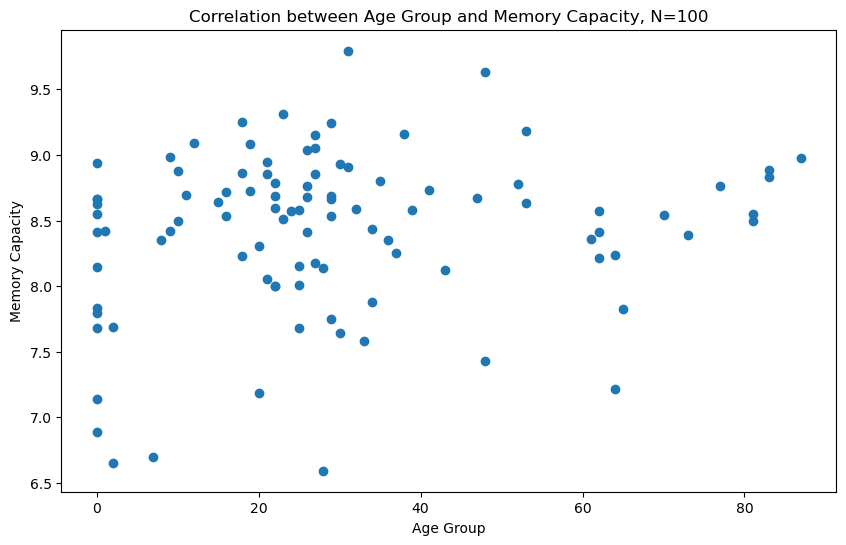

In [11]:
#start a dataframe with the correlations 
df = pd.read_csv('ESNcpp/MC_by_age_sample_100.txt', header=None)
df.columns = ['Age Group', 'Memory Capacity', 'NARMA10']

#obtain a p value for the correlation between age group and memory capacity
from scipy.stats import pearsonr
correlation, p_value = pearsonr(df['Age Group'], df['Memory Capacity'])
print(f'Correlation: {correlation}, P-value: {p_value}')
#plot the correlation
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.scatter(df['Age Group'], df['Memory Capacity'], marker='o')
plt.xlabel('Age Group')
plt.ylabel('Memory Capacity')
plt.title('Correlation between Age Group and Memory Capacity, N=100')

Correlation: 0.25888800039215454, P-value: 8.890045235322017e-17


Text(0.5, 1.0, 'Correlation between Age Group and Memory Capacity, N=100')

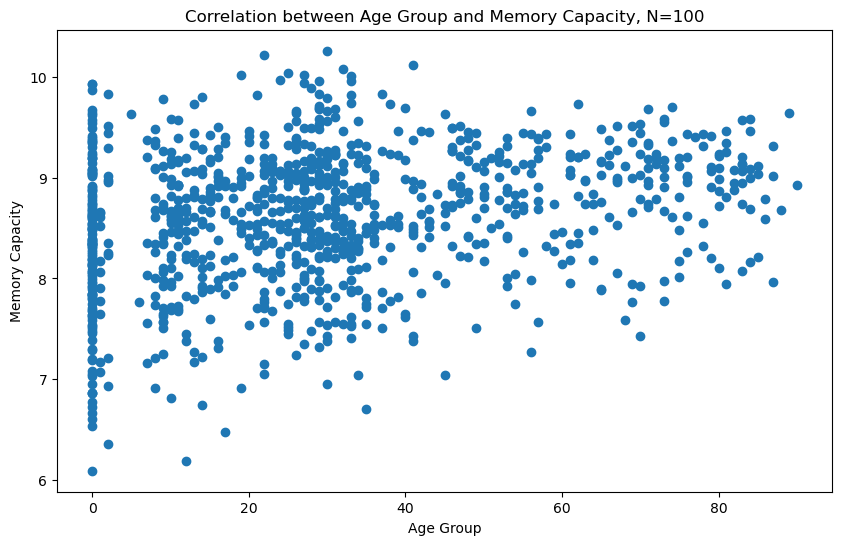

In [12]:
#start a dataframe with the correlations 
df = pd.read_csv('ESNcpp/MC_by_age_sample_1000.txt', header=None)
df.columns = ['Age Group', 'Memory Capacity']

#obtain a p value for the correlation between age group and memory capacity
from scipy.stats import pearsonr
correlation, p_value = pearsonr(df['Age Group'], df['Memory Capacity'])
print(f'Correlation: {correlation}, P-value: {p_value}')
#plot the correlation
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.scatter(df['Age Group'], df['Memory Capacity'], marker='o')
plt.xlabel('Age Group')
plt.ylabel('Memory Capacity')
plt.title('Correlation between Age Group and Memory Capacity, N=100')

There are many of each age, we can maybe avg out by age? 

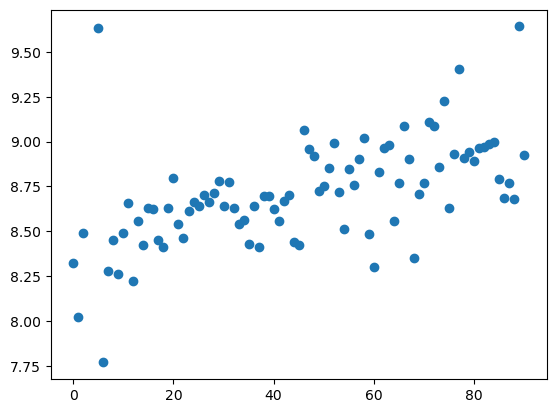

Correlation: 0.5675427900546511, P-value: 6.649194501110495e-09


In [13]:
df_by_age = (
    df.groupby('Age Group', as_index=False)['Memory Capacity']
      .mean()
      .sort_values('Age Group')
)

plt.scatter(df_by_age['Age Group'], df_by_age['Memory Capacity'], marker='o')
plt.show()

correlation, p_value = pearsonr(df_by_age['Age Group'], df_by_age['Memory Capacity'])
print(f'Correlation: {correlation}, P-value: {p_value}')


Questioning the hypothesis again, switch to NARMA which is more like Non linear

Correlation: -0.3138413455661121, P-value: 2.8390000464277953e-24


Text(0.5, 1.0, 'Correlation between Age Group and NARMA10, N=100')

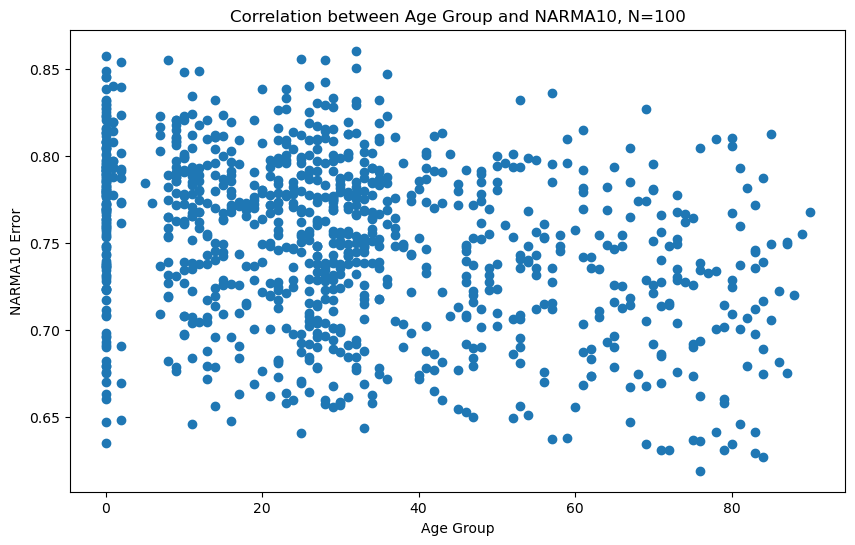

In [16]:
#start a dataframe with the correlations 
df = pd.read_csv('ESNcpp/MC_by_age_sample_100.txt', header=None)
df.columns = ['Age Group', 'Memory Capacity', 'NARMA10']

#obtain a p value for the correlation between age group and memory capacity
from scipy.stats import pearsonr
correlation, p_value = pearsonr(df['Age Group'], df['NARMA10'])
print(f'Correlation: {correlation}, P-value: {p_value}')
#plot the correlation
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.scatter(df['Age Group'], df['NARMA10'], marker='o')
plt.xlabel('Age Group')
plt.ylabel('NARMA10 Error' )
plt.title('Correlation between Age Group and NARMA10, N=100')

Seems to indicate the same thing. lower spectral gap in older brains leads to better "thinking". So we can try to use input regions as input for the ESN to see how well the signal propagates throuht the young less homogeneous brain and see if this tendency is reversed.

Correlation between Age Group and Memory Capacity: 0.24108648355648132, P-value: 1.1212587046129528e-14
Correlation between Age Group and NARMA10: -0.24929956817367133, P-value: 1.281918455772947e-15
Correlation between Age Group and Memory Capacity BIO ART INPUT: 0.32807912752467283, P-value: 1.6912240128341017e-26
Correlation between Age Group and NARMA10 BIO ART INPUT: -0.32640874416009863, P-value: 3.129300933230085e-26


Text(0.5, 1.0, 'Correlation between Age Group and Memory Capacity, N=1000, BIO ART INPUT')

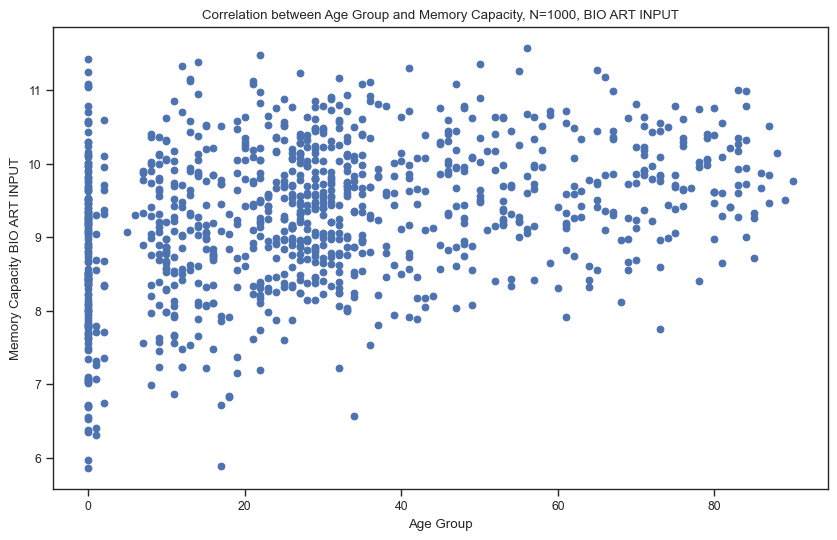

In [21]:
#start a dataframe with the correlations 
df = pd.read_csv('ESNcpp/MC_NARMA_bio_art_input.txt', header=None)
df.columns = ['Age Group', 'Memory Capacity', 'NARMA10', 'Memory Capacity BIO ART INPUT', 'NARMA10 BIO ART INPUT']

#obtain a p value for the correlation between age group and memory capacity
from scipy.stats import pearsonr
#calculate all pearson coeffs por all columns with age group
for col in df.columns[1:]:
     correlation, p_value = pearsonr(df['Age Group'], df[col])
     print(f'Correlation between Age Group and {col}: {correlation}, P-value: {p_value}')
#plot the correlation
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.scatter(df['Age Group'], df['Memory Capacity BIO ART INPUT'], marker='o')
plt.xlabel('Age Group')
plt.ylabel('Memory Capacity BIO ART INPUT' )
plt.title('Correlation between Age Group and Memory Capacity, N=1000, BIO ART INPUT')

C:\Users\Ale\AppData\Local\Temp\ipykernel_11676\2131444102.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=res_df, x='r', y='Label', palette=colors, ax=ax, orient='h')


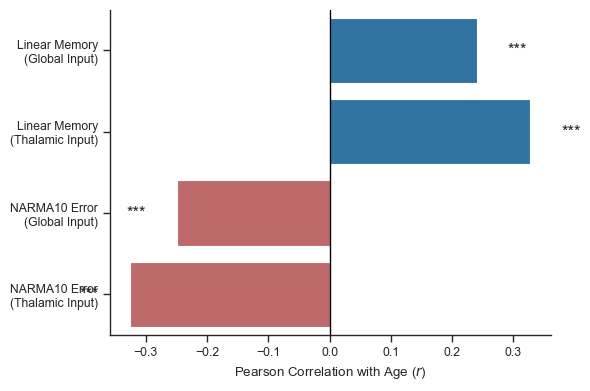

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

# 1. Load and prepare data
df = pd.read_csv('ESNcpp/MC_NARMA_bio_art_input.txt', header=None)
df.columns = ['Age', 'MC_Art', 'NARMA_Art', 'MC_Bio', 'NARMA_Bio']

results = []
for m in ['MC_Art', 'MC_Bio', 'NARMA_Art', 'NARMA_Bio']:
    r, p = pearsonr(df['Age'], df[m])
    results.append({'Metric': m, 'r': r, 'p': p})
res_df = pd.DataFrame(results)

# Clean labels for the paper
label_map = {
    'MC_Art': 'Linear Memory\n(Global Input)',
    'MC_Bio': 'Linear Memory\n(Thalamic Input)',
    'NARMA_Art': 'NARMA10 Error\n(Global Input)',
    'NARMA_Bio': 'NARMA10 Error\n(Thalamic Input)'
}
res_df['Label'] = res_df['Metric'].map(label_map)

# 2. Assign significance stars
def get_stars(p):
    if p < 0.001: return '***'
    if p < 0.01: return '**'
    if p < 0.05: return '*'
    return 'ns'
res_df['stars'] = res_df['p'].apply(get_stars)

# 3. Plotting
sns.set_theme(style="ticks", context="paper")
fig, ax = plt.subplots(figsize=(6, 4))

# Group colors by task (Blue for MC, Red for NARMA)
colors = ['tab:blue', 'tab:blue', 'indianred', 'indianred']
sns.barplot(data=res_df, x='r', y='Label', palette=colors, ax=ax, orient='h')

# Formatting
ax.axvline(0, color='black', linewidth=1)
for i, row in res_df.iterrows():
    align = 'left' if row['r'] > 0 else 'right'
    offset = 0.05 if row['r'] > 0 else -0.05
    ax.text(row['r'] + offset, i, row['stars'], va='center', ha=align, fontsize=12)

ax.set_xlabel(r'Pearson Correlation with Age ($r$)')
ax.set_ylabel('')
sns.despine()

plt.tight_layout()
plt.show()